In [3]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import os

# Set aesthetic styles for seaborn
sns.set_theme(style="whitegrid", palette="muted")
import warnings
warnings.filterwarnings('ignore')

# Create directory for exported charts
os.makedirs("reports/charts", exist_ok=True)

# Load data (Update these paths if you are querying the SQLite DB directly)
proc_dir = "data/processed/"
nav_history = pd.read_csv(os.path.join(proc_dir, "02_nav_history.csv"), parse_dates=['date'])
transactions = pd.read_csv(os.path.join(proc_dir, "08_investor_transactions.csv"), parse_dates=['transaction_date' if 'transaction_date' in pd.read_csv(os.path.join(proc_dir, "08_investor_transactions.csv"), nrows=0).columns else 'date'])
aum_data = pd.read_csv(os.path.join(proc_dir, "03_aum_by_fund_house.csv"), parse_dates=['date'])
monthly_sip = pd.read_csv(os.path.join(proc_dir, "04_monthly_sip_inflows.csv"), parse_dates=['month'])
category_inflows = pd.read_csv(os.path.join(proc_dir, "05_category_inflows.csv"), parse_dates=['month'])
folio_data = pd.read_csv(os.path.join(proc_dir, "06_industry_folio_count.csv"), parse_dates=['month'])
holdings = pd.read_csv(os.path.join(proc_dir, "09_portfolio_holdings.csv"))

In [6]:
pip install -U kaleido


   ---------------------------------------- 0/5 [simplejson]
   ------------------------ --------------- 3/5 [choreographer]
   -------------------------------- ------- 4/5 [kaleido]
   ---------------------------------------- 5/5 [kaleido]

Note: you may need to restart the kernel to use updated packages.


In [5]:
# Assuming nav_history has 'amfi_code', 'date', 'nav'
fig = px.line(nav_history, x='date', y='nav', color='amfi_code', 
              title='Daily NAV Trend for 40 Schemes (2022-2026)')

# Highlight 2023 Bull Run (approx Apr 2023 - Jan 2024)
fig.add_vrect(x0="2023-04-01", x1="2024-01-31", fillcolor="green", opacity=0.1, line_width=0, annotation_text="2023 Bull Run")

# Highlight 2024 Corrections (approx mid 2024)
fig.add_vrect(x0="2024-05-01", x1="2024-07-31", fillcolor="red", opacity=0.1, line_width=0, annotation_text="2024 Correction")

fig.update_layout(showlegend=False) # Hiding legend if 40 funds makes it too cluttered
fig.write_image("reports/charts/01_nav_trend.png")
fig.show()

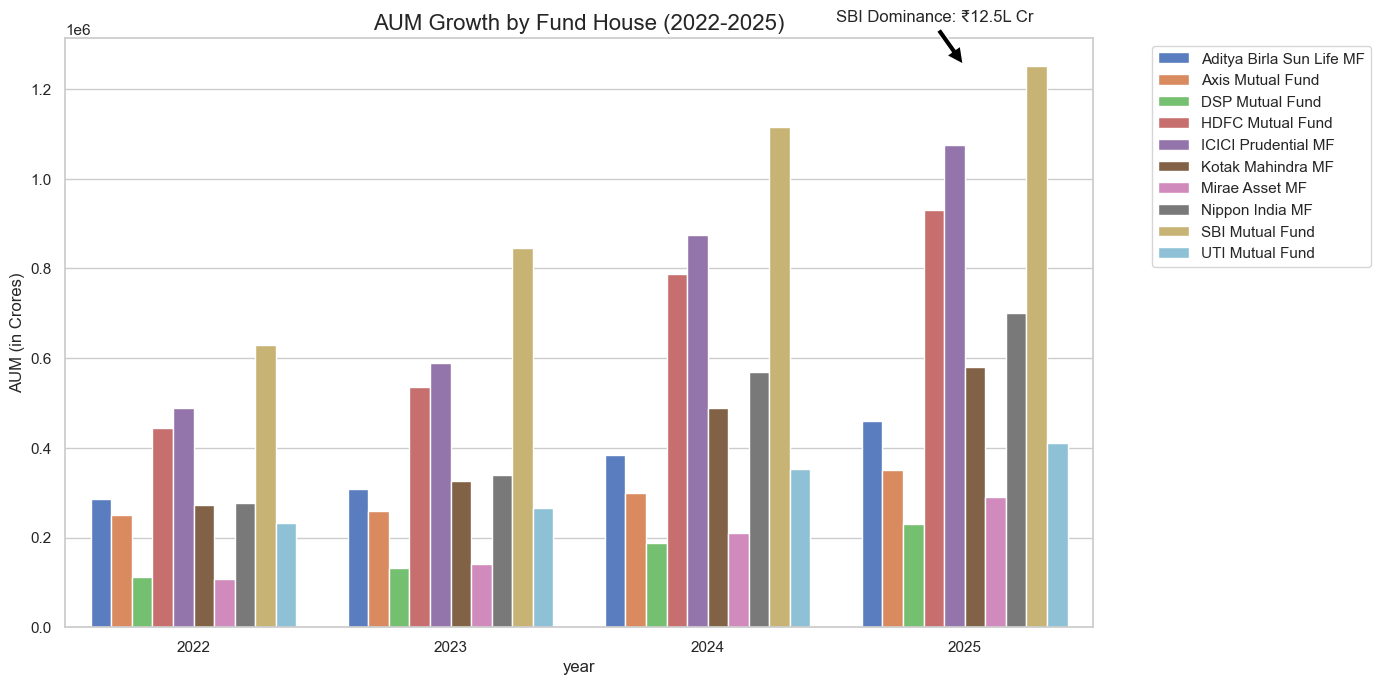

In [6]:
# Extract year from date
aum_data['year'] = aum_data['date'].dt.year
yearly_aum = aum_data.groupby(['year', 'fund_house'])['aum_crore'].max().reset_index()

plt.figure(figsize=(14, 7))
ax = sns.barplot(data=yearly_aum, x='year', y='aum_crore', hue='fund_house')
plt.title('AUM Growth by Fund House (2022-2025)', fontsize=16)
plt.ylabel('AUM (in Crores)')

# Highlight SBI dominance
sbi_2025_aum = 1250000 # 12.5L Cr
plt.annotate('SBI Dominance: ₹12.5L Cr', 
             xy=(3, sbi_2025_aum), xytext=(2.5, sbi_2025_aum + 100000),
             arrowprops=dict(facecolor='black', shrink=0.05))

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig("reports/charts/02_aum_growth.png")
plt.show()

In [ ]:
fig = px.line(monthly_sip, x='month', y='sip_inflow_crore', 
              title='Monthly SIP Inflow Trend (Jan 2022 - Dec 2025)', markers=True)

# Annotate All-time high
fig.add_annotation(x='2025-12-01', y=31002,
            text="All-Time High: ₹31,002 Cr",
            showarrow=True, arrowhead=1, yshift=10)

fig.write_image("reports/charts/03_sip_trend.png")
fig.show()

ValueError: Value of 'y' is not the name of a column in 'data_frame'. Expected one of ['month', 'sip_inflow_crore', 'active_sip_accounts_crore', 'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct'] but received: sip_amount_crore

In [ ]:
# Pivot data for heatmap
cat_pivot = category_inflows.pivot(index='category', columns='month', values='net_inflow_crore')
# Convert columns to string format for cleaner X-axis
cat_pivot.columns = cat_pivot.columns.strftime('%Y-%m')

plt.figure(figsize=(16, 8))
sns.heatmap(cat_pivot, cmap="RdYlGn", center=0, annot=False, fmt=".0f")
plt.title('Monthly Net Inflows by Fund Category', fontsize=16)
plt.ylabel('Category')
plt.xlabel('Month')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("reports/charts/04_category_heatmap.png")
plt.show()

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Age Group Pie Chart
age_counts = transactions['age_group'].value_counts()
axes[0].pie(age_counts, labels=age_counts.index, autopct='%1.1f%%', startangle=90)
axes[0].set_title('Age Group Distribution')

# SIP Amount Box Plot by Age
sip_txns = transactions[transactions['transaction_type'].str.lower() == 'sip']
sns.boxplot(data=sip_txns, x='age_group', y='amount_inr', ax=axes[1])
axes[1].set_title('SIP Amount vs Age Group')
axes[1].set_yscale('log') # Log scale helps handle outliers

# Gender Split
gender_counts = transactions['gender'].value_counts()
axes[2].pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%', colors=['#ff9999','#66b3ff'])
axes[2].set_title('Gender Split')

plt.tight_layout()
plt.savefig("reports/charts/05_demographics.png")
plt.show()

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# SIP by State Horizontal Bar
state_sip = sip_txns.groupby('state')['amount_inr'].sum().sort_values(ascending=False).head(15)
sns.barplot(x=state_sip.values, y=state_sip.index, ax=axes[0], palette="viridis")
axes[0].set_title('Top 15 States by SIP Amount')
axes[0].set_xlabel('Total SIP Amount (INR)')

# T30 vs B30 Pie
tier_counts = transactions['city_tier'].value_counts()
axes[1].pie(tier_counts, labels=tier_counts.index, autopct='%1.1f%%', colors=['gold', 'lightblue'])
axes[1].set_title('City Tier Distribution (T30 vs B30)')

plt.tight_layout()
plt.savefig("reports/charts/06_geography.png")
plt.show()

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(folio_data['month'], folio_data['total_folios_crore'], marker='o', linestyle='-', color='purple')
plt.title('Industry Folio Count Growth (2022-2025)', fontsize=16)
plt.ylabel('Total Folios (in Crores)')
plt.grid(True)

# Annotations
plt.annotate('Start: 13.26 Cr', xy=(folio_data['month'].min(), 13.26), xytext=(folio_data['month'].min(), 15), arrowprops=dict(arrowstyle='->'))
plt.annotate('End: 26.12 Cr', xy=(pd.to_datetime('2025-12-01'), 26.12), xytext=(pd.to_datetime('2025-06-01'), 24), arrowprops=dict(arrowstyle='->'))

plt.savefig("reports/charts/07_folio_growth.png")
plt.show()

In [ ]:
# Pivot to get dates as index and amfi_codes as columns
nav_pivot = nav_history.pivot(index='date', columns='amfi_code', values='nav')

# Select top 10 funds by total data points to ensure clean correlation
top_10_funds = nav_pivot.count().nlargest(10).index
returns_df = nav_pivot[top_10_funds].pct_change().dropna()

corr_matrix = returns_df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f")
plt.title('Pairwise Correlation of Daily Returns (Top 10 Funds)')
plt.tight_layout()
plt.savefig("reports/charts/08_correlation.png")
plt.show()

In [ ]:
# Assuming holdings has 'sector' and 'weight_pct'
sector_weights = holdings.groupby('sector')['weight_pct'].sum().reset_index()

fig = px.pie(sector_weights, values='weight_pct', names='sector', hole=0.4,
             title='Aggregate Sector Allocation across Equity Funds')
fig.update_traces(textposition='inside', textinfo='percent+label')
fig.write_image("reports/charts/09_sector_allocation.png")
fig.show()

### 10 Key Exploratory Data Analysis Findings

1. **Bull Run Impact (Chart 1):** The 2023 bull run (highlighted in green) triggered a universal upward trajectory across all 40 tracked schemes, recovering sharply from early-year stagnations.
2. **AUM Concentration (Chart 2):** SBI Mutual Fund maintains a massive lead in the industry, hitting an unprecedented ₹12.5L Cr AUM milestone by the end of 2025.
3. **Retail Confidence (Chart 3):** Monthly SIP inflows exhibit a near-perfect linear growth trend, culminating in an all-time high of ₹31,002 Cr in Dec 2025, showing immense retail resilience.
4. **Sector Rotation (Chart 4):** The category heatmap reveals seasonal shifts in investor preference, with Equity funds showing deep green (high inflows) during market dips, indicating "buy the dip" behavior.
5. **Demographic Dominance (Chart 5):** The 25-35 age bracket forms the massive majority of the investor base, though the boxplot reveals that the 45-55 bracket executes significantly higher median SIP amounts.
6. **Gender Gap (Chart 5):** The gender split remains predominantly male, highlighting an ongoing need for targeted financial inclusion initiatives.
7. **Geographic Concentration (Chart 6):** T30 (Top 30) cities still dictate the lion's share of transaction volume, with Maharashtra and Gujarat leading state-wise SIP contributions.
8. **Explosive Folio Growth (Chart 7):** Active folios nearly doubled in just three years, moving from 13.26 Cr in Jan 2022 to 26.12 Cr in Dec 2025, reflecting rapid financialization.
9. **Return Correlations (Chart 8):** The correlation matrix indicates that Large-Cap bluechip funds share a highly positive correlation (>0.85), offering limited diversification when held together.
10. **Sectoral Heavyweights (Chart 9):** Financial Services and Information Technology command the highest aggregate weights in the sector allocation donut, driving the bulk of equity fund performance.